In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.random as jrd
import jax.numpy as jnp
import optax
from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.landscape_visuals import *
from evoscape.jax import pytree_to_landscape
from evoscape.jax.regimes import mr_const
from evoscape.jax.dynamics import get_cell_states
from evoscape.jax.losses import origin_leading_fitness, biseparating_fitness
from evoscape.jax.experiment import Experiment
from evoscape.jax.utils import init_cell, make_movie_landscape
from jax.scipy.special import kl_div, entr
plt.style.use('default')
plt.rcParams.update({'figure.dpi': 100})
plt.rcParams.update({'font.size': 15})

%load_ext autoreload

In [2]:
# Landscape with one regime + simple visualization
%autoreload

# Definition of the modules of the landscape: to be constructed accordingly

# M1 = Node(x=-1.5, y=0., a=1.5, s=1.)
# M2 = Node(x=3., y=0., a=2., s=0.8)


M1 = Node(x=-0.5, y=0., a=1.5, s=1.)
M2 = Node(x=0.5, y=0., a=2., s=0.8)

module_list = [M1, M2]


# M1 = Node(x=-3., y=0., a=3., s=1.)
# M2 = Node(x=4., y=0., a=3., s=1.)
# M3 = Node (x= 2., y= 3., a= 3.,s=1.)

# module_list = [M1, M2,M3]

for M in module_list:
    print(M)

# Definition of the landscape
landscape = Landscape(module_list, A0 = 0.01, regime=mr_const, n_regimes=1)
print(landscape)


#Numerical constants for simulation
n, init_cond, init_noise, t0,tf, nt, ndt, noise, lr, steps=200, jnp.array([0.,1.]), 0.5, 0., 10., 51, 50, 0.5, 0.001, 400

q_init = jnp.tile(init_cond[:, None], (1, n))

# Selection of the get_states function 
get_states = get_cell_states


T, μ, λ, q_prob =1., 50., 10., (0.4,0.6)

loss_params = T, μ, λ, q_prob
fitness = biseparating_fitness
# For signal regime
signal_param = None

opt = optax.adam(lr)

Node: x=-0.5; y=0.0; a=1.5; s=1.
Node: x=0.5; y=0.0; a=2.; s=0.8
Landscape with modules:
Node: x=-0.5; y=0.0; a=1.5; s=1.,
Node: x=0.5; y=0.0; a=2.; s=0.8


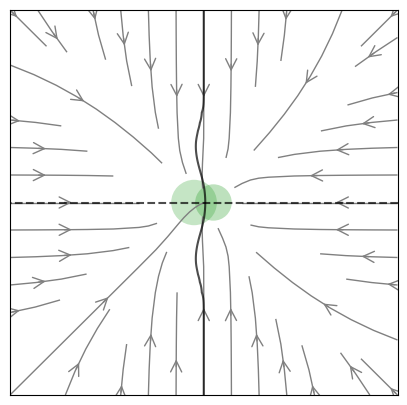

In [3]:
# Parameters of vizualisation 
L = 10.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

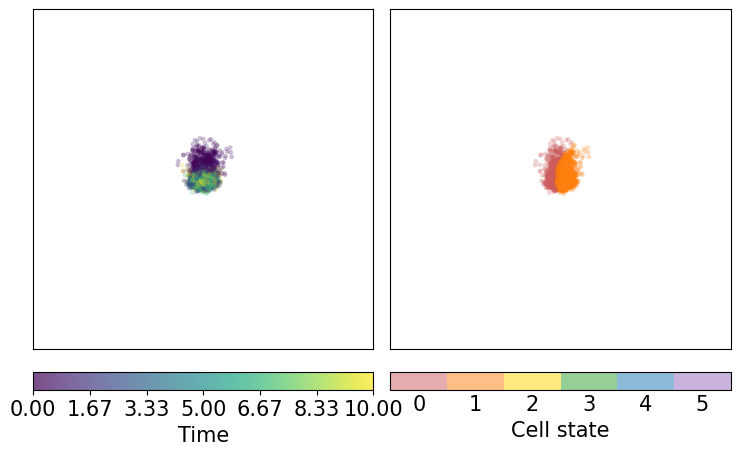

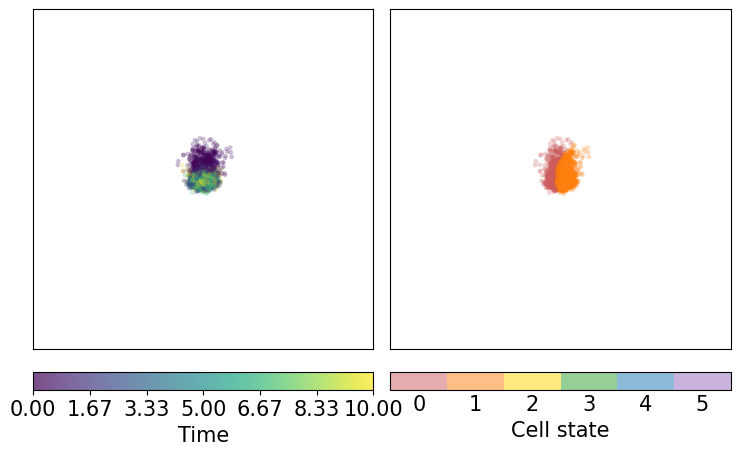

In [4]:
landscape.init_cells(n,landscape.init_cond,noise=init_noise)
get_and_plot_traj(landscape,t0,tf,nt,L,noise)

In [5]:
# n_frames = 100
# time_pars = (t0,tf, n_frames)
# print(landscape.n_regimes)
# labels = [f"regime {i}" for i in range(0,landscape.n_regimes+1)]
# print(labels)
# make_movie_discrete(landscape, xx, yy, labels, time_pars, n, noise, init_cond=landscape.init_cond,
#                         circles=True, circle_opacity=0.1, density=0.65, nullclines=False,
#                         fps=10, save_dir='../figures/', filename='start_traj.gif')

# save_dir = '../temp/figures/'
# import os, glob
# for f in glob.glob(save_dir + "frame_*.png"):
#     os.remove(f)

In [6]:
# dynamic, static, losses, traj, states= run_experiment(
#     landscape,
#     key,
#     n,
#     init_cell,
#     t0,
#     tf,
#     nt,
#     ndt,
#     noise,
#     iterations,
#     η,
#     get_states,
#     loss_function,
#     loss_param,
#     signal_param
#     )

pytree = Experiment(landscape = landscape)

print(pytree.dynamic)
pytree.set_initial_conditions(q_init= q_init)
#We should depreciate set_regime as It shouldn't have to be set manually
pytree.set_regime_params(signal_param = signal_param)

pytree.set_simulation(n=n, init_noise=init_noise,t0=t0, tf=tf, nt= nt, ndt= ndt, noise=noise)

pytree.set_state_probs(get_cell_states=get_states)

# losses = pytree.optimize(user_fitness=fitness, fitness_params=loss_params, steps=steps, lr= lr)

losses = pytree.optimize(user_fitness=fitness, fitness_params=loss_params, steps=steps, optimizer=opt)

dynamic, static, traj, states = pytree.dynamic, pytree.static, pytree.trajectories, pytree.states

LandscapeDynamic(module=ModuleDynamic(x=Array([-0.5,  0.5], dtype=float32), y=Array([0., 0.], dtype=float32), a=Array([1.5, 2. ], dtype=float32), s=Array([1. , 0.8], dtype=float32)))
Train step 0 : Loss = -0.04369351267814636
Train step 20 : Loss = -0.23898941278457642
Train step 40 : Loss = -0.2354237139225006
Train step 60 : Loss = -0.39174410700798035
Train step 80 : Loss = -0.5508939027786255
Train step 100 : Loss = -0.7054128646850586
Train step 120 : Loss = -0.8421980142593384
Train step 140 : Loss = -0.8436102867126465
Train step 160 : Loss = -0.8607525825500488
Train step 180 : Loss = -1.0112416744232178
Train step 200 : Loss = -0.9933435916900635
Train step 220 : Loss = -1.0859463214874268
Train step 240 : Loss = -1.2885221242904663
Train step 260 : Loss = -1.3327665328979492
Train step 280 : Loss = -1.6188974380493164
Train step 300 : Loss = -1.8726789951324463
Train step 320 : Loss = -2.1859567165374756
Train step 340 : Loss = -2.752652406692505
Train step 360 : Loss = -2.98

In [7]:
print(dynamic)

LandscapeDynamic(module=ModuleDynamic(x=Array([-0.9585164 ,  0.96023965], dtype=float32), y=Array([-0.63623106,  0.63743407], dtype=float32), a=Array([1.6141092, 1.7202765], dtype=float32), s=Array([1.0235661, 1.       ], dtype=float32)))


In [8]:
print(jnp.mean(states[:,-1]))

0.685


In [9]:
final_coord = traj[:,:,-1]

module_coord = jnp.stack((dynamic.module.x,dynamic.module.y))
m = module_coord.shape[1]
dist_squared = jnp.sum((final_coord.T[:, :, None] - module_coord)**2, axis=1)

weights = jnp.exp(-dist_squared / T)

P = weights / (jnp.sum(weights, axis=1, keepdims=True))

p_j = jnp.mean(P, axis=0)

loss_uniform = jnp.mean(kl_div(p_j,jnp.array(q_prob)))

uniform = jnp.ones_like(P) / P.shape[1]

loss_particle = -jnp.mean(
    jnp.sum(kl_div(P, uniform), axis=1)
)

print(P[:5,:], μ * loss_uniform, λ * loss_particle, losses[-1], jnp.mean(jnp.argmax(P,axis=1)))

[[0.9689437  0.03105631]
 [0.00919934 0.9908006 ]
 [0.00182148 0.99817854]
 [0.11005043 0.8899496 ]
 [0.05045306 0.94954693]] 0.2703637 -5.0099044 -4.7164197 0.68


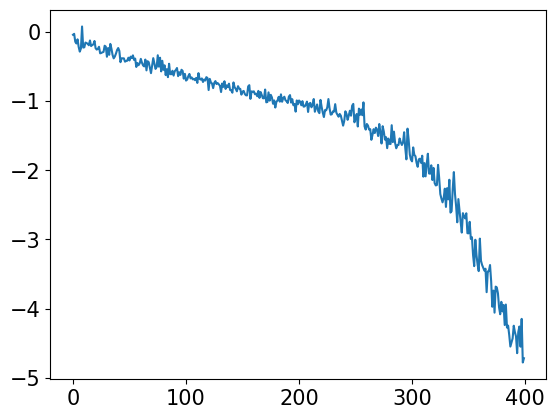

In [10]:
plt.plot(losses)

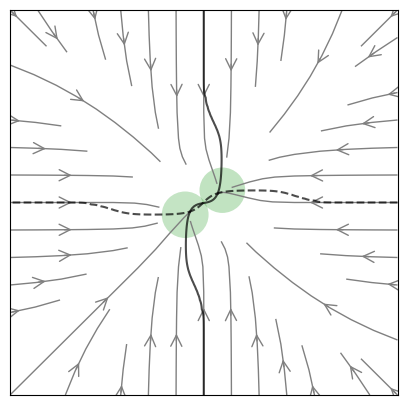

In [11]:
l = pytree.get_landscape()
fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')

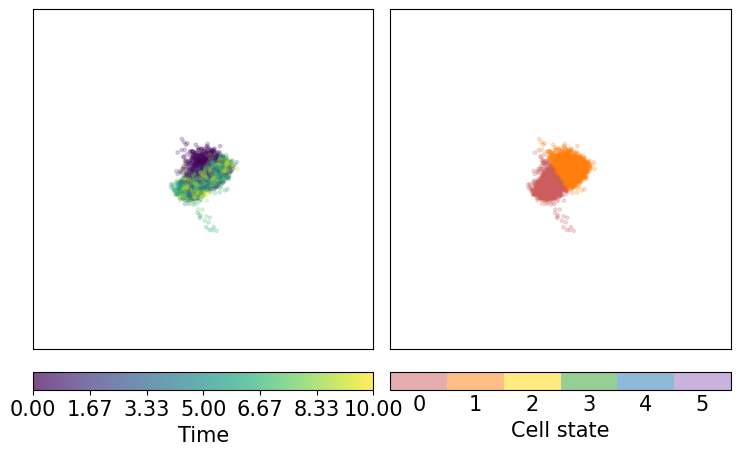

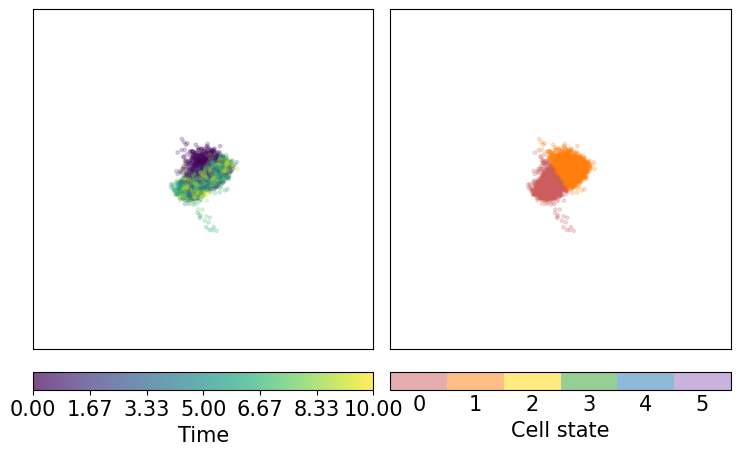

In [12]:
# Put back the coordinates of the cells at the init_ as the are
l.init_cells(n,static.init_cond,noise=init_noise)
get_and_plot_traj(l,t0,tf,nt,L,noise) 

In [13]:
n_frames = 100
time_pars = (t0,tf, n_frames)
print(l.n_regimes)
labels = [f"regime {i}" for i in range(0,l.n_regimes+1)]
print(labels)
make_movie_discrete(l, xx, yy, labels, time_pars, n, noise, init_cond=l.init_cond,
                        circles=True, circle_opacity=0.1, density=0.65, nullclines=False,
                        fps=10, save_dir='../temp/figures/', filename='end_traj.gif')

save_dir = '../temp/figures/'
import os, glob
for f in glob.glob(save_dir + "frame_*.png"):
    os.remove(f)

1
['regime 0', 'regime 1']
Movie saved to ../temp/figures/end_traj.gif


In [14]:
n_frames = steps//10
make_movie_landscape(pytree.dynamic_vals,static, xx, yy, n_frames)